In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA
from utils import load_images
import joblib
import pathlib
from pathlib import Path

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")

In [3]:
model_list = []
for entry in basepath.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        model_list.append(model)

In [4]:
model_list

[FastICA(n_components=40, random_state=752767290, whiten=True),
 FastICA(n_components=40, random_state=3653403230, whiten=True),
 FastICA(n_components=40, random_state=70985653, whiten=True),
 FastICA(n_components=40, random_state=323153948, whiten=True),
 FastICA(n_components=40, random_state=1322117303, whiten=True),
 FastICA(n_components=40, random_state=2195314464, whiten=True),
 FastICA(n_components=40, random_state=2735729614, whiten=True),
 FastICA(n_components=40, random_state=175979944, whiten=True),
 FastICA(n_components=40, random_state=1158725111, whiten=True)]

In [5]:
images = load_images(crop_size=36)

In [6]:
image_patches = images.reshape(20000, 3, 12, 3, 12).transpose(0, 1, 3, 2, 4).reshape(20000, 9, 12, 12)

In [7]:
image_patches.shape

(20000, 9, 12, 12)

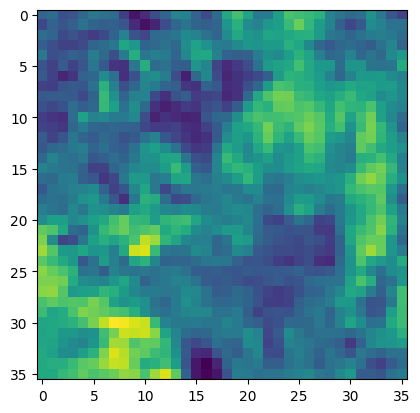

In [8]:
single_full_image = images[0]
plt.imshow(single_full_image)

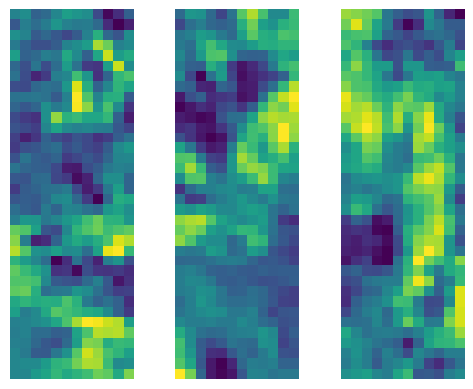

In [9]:
single_image_patches = image_patches[0]
fig, axs = plt.subplots(3, 3, dpi=100)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(single_image_patches[i])
    ax.axis("off")
plt.subplots_adjust(wspace=0, hspace=0)

In [10]:
image_patches = image_patches.transpose(1, 0, 2, 3)
image_patches.shape

(9, 20000, 12, 12)

In [11]:
zs = []
for images, model in zip(image_patches, model_list):
    images = images.reshape(images.shape[0], -1)
    z = model.transform(images)
    zs.append(z)
    

In [12]:
zs[0].shape

(20000, 40)

In [13]:
component_matrices = []
for model in model_list:
    component_matrices.append(model.components_)
component_matrices = np.array(component_matrices)

In [14]:
component_matrices.shape

(9, 40, 144)

In [15]:
single_image_patches.shape

(9, 12, 12)

In [16]:
single_image_patches.shape, component_matrices.T.shape

((9, 12, 12), (144, 40, 9))

In [17]:
single_image_patches_flat = single_image_patches.reshape(9, -1)
single_image_patches_flat.shape

(9, 144)

In [18]:
np.dot(single_image_patches_flat, component_matrices.transpose(0, 2, 1)).shape

(9, 9, 40)

In [19]:
single_image_patches_flat.shape, component_matrices.transpose(0, 2, 1).shape

((9, 144), (9, 144, 40))

In [20]:
(single_image_patches_flat @ component_matrices.transpose(0, 2, 1)).shape

(9, 9, 40)

In [21]:
mixing_matrices = []
for model in model_list:
    mixing_matrices.append(model.mixing_)

In [22]:
mixing_matrices = np.array(mixing_matrices)
mixing_matrices.shape

(9, 144, 40)

In [23]:
single_full_image.shape

(36, 36)

In [24]:
component_matrices = []
for model in model_list:
    component_matrices.append(model.components_)
component_matrices = np.array(component_matrices)

In [25]:
component_matrices.shape

(9, 40, 144)

In [26]:
# convert 36x36 image to 12x12 patches
single_image_patches = single_full_image.reshape(3, 12, 3, 12).transpose(0, 2, 1, 3).reshape(9, 12, 12)

In [27]:
single_image_patches.shape

(9, 12, 12)

In [28]:
s = single_image_patches.reshape(single_image_patches.shape[0], -1)[:, np.newaxis]
s.shape

(9, 1, 144)

In [29]:
s_dash = single_image_patches.reshape(single_image_patches.shape[0], -1)[:, :, np.newaxis]

In [30]:
(component_matrices @ s_dash).shape

(9, 40, 1)

In [31]:
ica_model = FastICA()

In [32]:
ica_model.components_ = component_matrices
ica_model.mixing_ = mixing_matrices

In [35]:
ica_model._whiten = True

In [37]:
component_matrices.shape, mixing_matrices.shape

((9, 40, 144), (9, 144, 40))

In [ ]:
class PanelICA:
    def __init__(self, ica_models):
        self.ica_models = ica_models

    def transform(self, X):
        zs = []
        for images, model in zip(X, self.ica_models):
            images = images.reshape(images.shape[0], -1)
            z = model.transform(images)
            zs.append(z)
        return zs
    

In [39]:
(single_image_patches.reshape(single_image_patches.shape[0], -1)[:, np.newaxis] @ mixing_matrices).shape

(9, 1, 40)

In [34]:
mixing_matrices.shape

(9, 144, 40)

In [37]:
np.dot(single_image_patches.reshape(single_image_patches.shape[0], -1), mixing_matrices).shape

(9, 9, 40)

In [28]:
36 * 36

1296

In [29]:
zs_full = np.concatenate(zs, axis=1)
zs_full.shape

(20000, 360)

In [30]:
ica_model_2 = FastICA(n_components=40, random_state=0)

In [31]:
ica_model_2.fit(zs_full)

/usr/local/lib/python3.8/dist-packages/sklearn/decomposition/_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


FastICA(n_components=40, random_state=0)

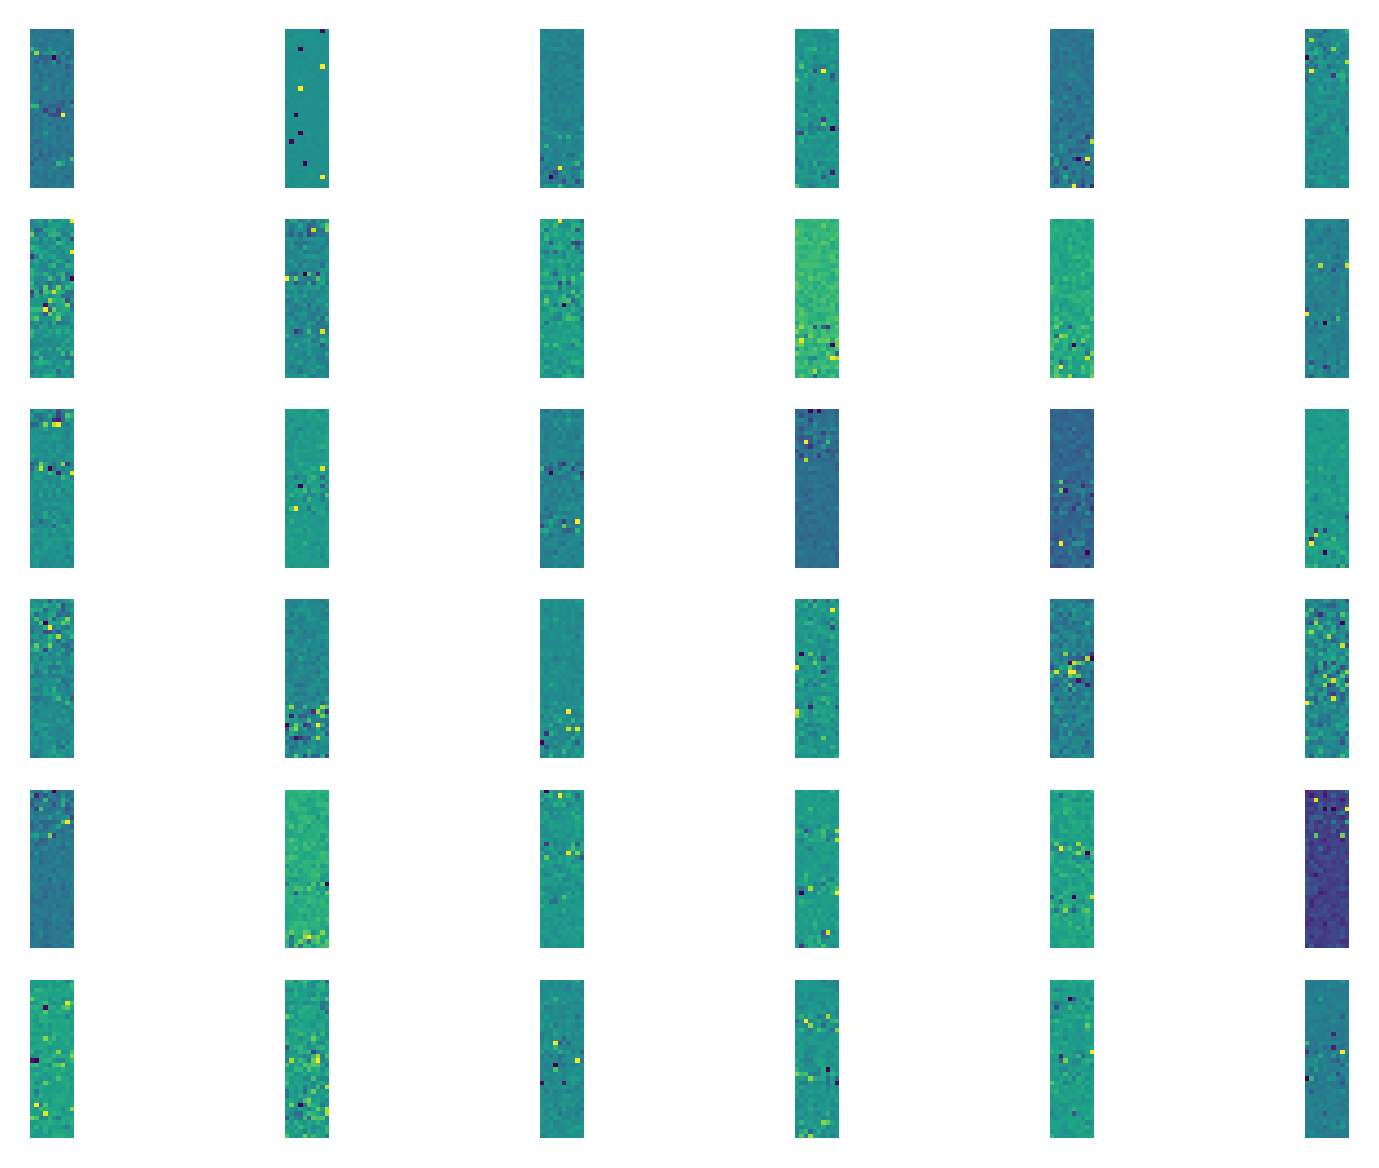

In [32]:
mixing_matrix_2 = ica_model_2.mixing_
fig, axs = plt.subplots(6, 6, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(mixing_matrix_2[:, i].reshape(36, 10))
    ax.axis("off")